In [ ]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # ("Chen2020")
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"}

model = pybamm.lithium_ion.DFN(options=options)

In [176]:
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                         "Total heat transfer coefficient [W.m-2.K-1]": 10.0,
                         "Cell cooling surface area [m2]": 0.00531,
                         "Cell volume [m3]": 2.42e-05,
                         "Cell thermal expansion coefficient [m.K-1]": 1.1e-06,})

In [177]:
pybamm.constants.R

Constant(-0x3c7569de2a08f9c7, R, children=[], domains={})

In [178]:
#TempK = model.variables["Cell temperature [K]"]
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4
    EaD = 50000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius
parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})

In [179]:
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002})
# parameter_values.update({"Ratio of lithium moles to SEI moles": 1.0*2})
# parameter_values.update({"Inner SEI partial molar volume [m3.mol-1]": 9.585e-05*0.5})
#parameter_values.update({"Outer SEI partial molar volume [m3.mol-1]": 9.585e-05*0.5})
# parameter_values.update({"SEI resistivity [Ohm.m]": 200000.0*0.1})
#parameter_values.update({"EC diffusivity [m2.s-1]": 2e-18*0+2.5e-22*4})
# parameter_values.update({"EC initial concentration in electrolyte [mol.m-3]": 4541.0*1})
# parameter_values.update({"SEI growth activation energy [J.mol-1]": 38000.0*0})

In [180]:
def graphite_volume_change_Ai2020(sto):
    """
    Graphite particle volume change as a function of stoichiometry [1, 2].

    References
    ----------
     .. [1] Ai, W., Kraft, L., Sturm, J., Jossen, A., & Wu, B. (2020).
     Electrochemical Thermal-Mechanical Modelling of Stress Inhomogeneity in
     Lithium-Ion Pouch Cells. Journal of The Electrochemical Society, 167(1), 013512
      DOI: 10.1149/2.0122001JES.
     .. [2] Rieger, B., Erhard, S. V., Rumpf, K., & Jossen, A. (2016).
     A new method to model the thickness change of a commercial pouch cell
     during discharge. Journal of The Electrochemical Society, 163(8), A1566-A1575.

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stoichiometry, dimensionless
        should be R-averaged particle concentration
    c_s_max : :class:`pybamm.Symbol`
        Maximum particle concentration [mol.m-3]

    Returns
    -------
    t_change:class:`pybamm.Symbol`
        volume change, dimensionless, normalised by particle volume
    """
    p1 = 145.907
    p2 = -681.229
    p3 = 1334.442
    p4 = -1415.710
    p5 = 873.906
    p6 = -312.528
    p7 = 60.641
    p8 = -5.706
    p9 = 0.386
    p10 = -4.966e-05
    t_change = (
        p1 * sto**9
        + p2 * sto**8
        + p3 * sto**7
        + p4 * sto**6
        + p5 * sto**5
        + p6 * sto**4
        + p7 * sto**3
        + p8 * sto**2
        + p9 * sto
        + p10
    )
    return t_change

In [181]:
def lico2_volume_change_Ai2020(sto):
    """
    lico2 particle volume change as a function of stoichiometry [1, 2].

    References
    ----------
     .. [1] Ai, W., Kraft, L., Sturm, J., Jossen, A., & Wu, B. (2020).
     Electrochemical Thermal-Mechanical Modelling of Stress Inhomogeneity in
     Lithium-Ion Pouch Cells. Journal of The Electrochemical Society, 167(1), 013512
      DOI: 10.1149/2.0122001JES.
     .. [2] Rieger, B., Erhard, S. V., Rumpf, K., & Jossen, A. (2016).
     A new method to model the thickness change of a commercial pouch cell
     during discharge. Journal of The Electrochemical Society, 163(8), A1566-A1575.

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stoichiometry, dimensionless
        should be R-averaged particle concentration

    Returns
    -------
    t_change:class:`pybamm.Symbol`
        volume change, dimensionless, normalised by particle volume
    """
    omega = pybamm.Parameter("Positive electrode partial molar volume [m3.mol-1]")
    c_s_max = pybamm.Parameter("Maximum concentration in positive electrode [mol.m-3]")
    t_change = omega * c_s_max * sto
    return t_change

In [ ]:
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode critical stress [Pa]": 60000000.0*1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         "Positive electrode critical stress [Pa]": 375000000.0*1,
                         "Positive electrode partial molar volume [m3.mol-1]": 1.25e-05,
                         "Negative electrode partial molar volume [m3.mol-1]": 3.1e-06,
                         "Negative electrode Young's modulus [Pa]": 15000000000.0,
                         "Negative electrode Poisson's ratio": 0.3,
                         "Positive electrode Poisson's ratio": 0.2,
                         "Positive electrode Young's modulus [Pa]": 375000000000.0,
                         "Negative electrode reference concentration for free of deformation [mol.m-3]"
                         "": 0.0,
                         "Positive electrode reference concentration for free of deformation [mol.m-3]"
                         "": 0.0,
                         "Negative electrode volume change": graphite_volume_change_Ai2020,
                         "Positive electrode volume change": lico2_volume_change_Ai2020,}, check_already_exists=False)

#parameter_values.update({"Positive electrode LAM constant exponential term": 2.0*1.1})
#parameter_values.update({"Negative electrode critical stress [Pa]": 60000000.0*0.0009})
#parameter_values.update({"Negative electrode LAM constant exponential term": 2.0*1.1})

#parameter_values.update({"Positive electrode critical stress [Pa]": 375000000.0*0.00001})




In [183]:
def plating_exchange_current_density_OKane2020(c_e, c_Li, T):
    """
    Exchange-current density for Li plating reaction [A.m-2].
    References
    ----------
    .. [1] O’Kane, Simon EJ, Ian D. Campbell, Mohamed WJ Marzook, Gregory J. Offer, and
    Monica Marinescu. "Physical origin of the differential voltage minimum associated
    with lithium plating in Li-ion batteries." Journal of The Electrochemical Society
    167, no. 9 (2020): 090540.
    Parameters
    ----------
    c_e : :class:`pybamm.Symbol`
        Electrolyte concentration [mol.m-3]
    c_Li : :class:`pybamm.Symbol`
        Plated lithium concentration [mol.m-3]
    T : :class:`pybamm.Symbol`
        Temperature [K]
    Returns
    -------
    :class:`pybamm.Symbol`
        Exchange-current density [A.m-2]
    """

    k_plating = pybamm.Parameter("Lithium plating kinetic rate constant [m.s-1]")

    return pybamm.constants.F * k_plating * c_e

In [184]:
#Plating paremeters update
parameter_values.update({"Typical plated lithium concentration [mol.m-3]": 1000.0,
                        "Lithium metal partial molar volume [m3.mol-1]": 1.3e-05,
                        "Exchange-current density for plating [A.m-2]"
                        "": plating_exchange_current_density_OKane2020 ,
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.0001,
                        "Lithium plating transfer coefficient": 0.65,
                        "Initial plated lithium concentration [mol.m-3]": 0.0,}, check_already_exists=False)


In [76]:
experiment01 = pybamm.Experiment(["Discharge at 0.1C until 2.5V"])
sim = pybamm.Simulation(model, experiment=experiment01, parameter_values=parameter_values) #,experiment=experiment
#sim = pybamm.Simulation(model)
sim.solve() #initial_soc=0.5, t_eval=[0,3700]
sim.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=10.152524560240831, step=0.10152524560240832…

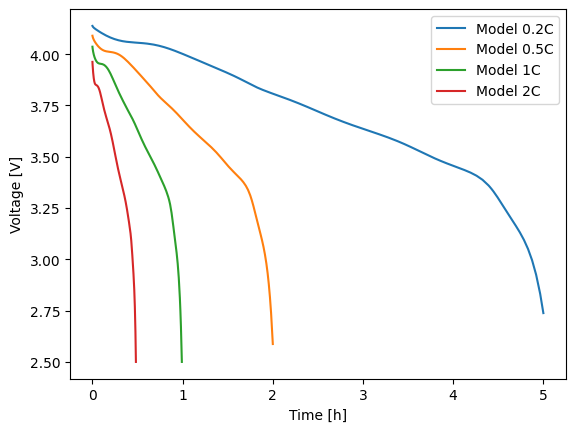

In [201]:
colors = ("r", "g", "b", "m")


def LG_M50_model(discharge): 
    
    model = pybamm.lithium_ion.DFN(options=options)
    sim = pybamm.Simulation(model=model, parameter_values=parameter_values, C_rate=discharge)
    sim.solve([0, 3600/discharge])
    return(
        sim.solution["Time [h]"].entries,
        #sim.solution["Discharge capacity [A.h]"].entries,
        sim.solution["Terminal voltage [V]"].entries
        )
 
    
for discharge in [0.2, 0.5, 1, 2]:
    
    model = LG_M50_model(discharge)
    plt.plot(*model,  linestyle="-", label=f"Model {discharge}C")
    


plt.xlabel("Time [h]")
#plt.xlabel("Discharge capacity [A.h]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.show()

In [77]:
sim.solution.plot(["Voltage [V]"])
sim.solution.plot(['Discharge capacity [A.h]'])

interactive(children=(FloatSlider(value=0.0, description='t', max=10.152524560240831, step=0.10152524560240832…

interactive(children=(FloatSlider(value=0.0, description='t', max=10.152524560240831, step=0.10152524560240832…

(array([2.25, 2.5 , 2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 ]),
 [Text(0, 2.25, '2.25'),
  Text(0, 2.5, '2.50'),
  Text(0, 2.75, '2.75'),
  Text(0, 3.0, '3.00'),
  Text(0, 3.25, '3.25'),
  Text(0, 3.5, '3.50'),
  Text(0, 3.75, '3.75'),
  Text(0, 4.0, '4.00'),
  Text(0, 4.25, '4.25'),
  Text(0, 4.5, '4.50')])

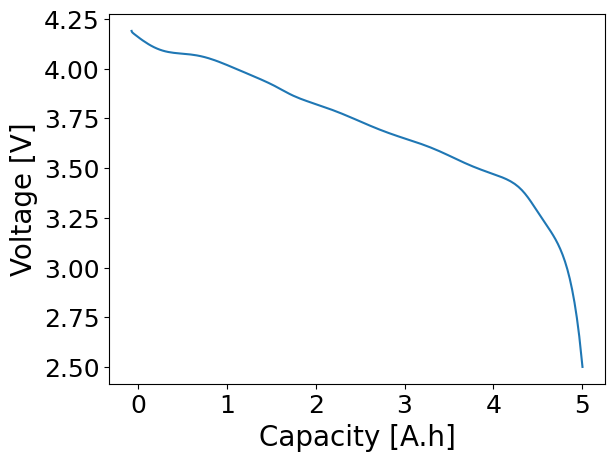

In [78]:
Qcell = sim.solution["Discharge capacity [A.h]"].entries
Vcell = sim.solution["Voltage [V]"].entries
plt.figure()
plt.plot( Qcell,Vcell)
#plt.plot(tt,Qcell )
plt.ylabel('Voltage [V]',fontsize=20)
plt.xlabel('Capacity [A.h]',fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

In [ ]:
# df_Vvssoc = {}
# df_Vvssoc = pd.DataFrame(df_Vvssoc)
# df_Vvssoc["soc"] = 1-Qcell/Qcell[-1]
# df_Vvssoc["Vcell"] = Vcell

# df_Vvssoc.to_csv(f"{current_directory}/paperStudies/QvsV01C.csv")

In [32]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [33]:
#Cases for calendar ageing

from itertools import product

temp_list2 = [10, 25, 45]
soc_list2 = [30, 60, 100]

calendar_cases = list(product(temp_list2, soc_list2))

df22 = pd.DataFrame(calendar_cases, columns= ["Temperature", "SoC"])
df22.insert(0, "Case", range(1, len(df2)+1))
df22.to_csv(f"{current_directory}/paperStudies/Cases_for_Calendar_ageing.csv", index=False)



In [34]:
df22

,Case,Temperature,SoC
0,1,10,30
1,2,10,60
2,3,10,100
3,4,25,30
4,5,25,60
5,6,25,100
6,7,45,30
7,8,45,60
8,9,45,100


In [124]:
df01c = pd.read_csv(f"{current_directory}/paperStudies/QvsV01C.csv")

x01c = df01c["soc"].to_numpy()
y01c = df01c["Vcell"].to_numpy()
x01c_scaled = (x01c-x01c.min())/(x01c.max()-x01c.min())
# idx = np.argsort(x01c_scaled)
# y01c = y01c[idx]

# x_new = 0.7
# y_new = np.interp(x_new, x01c_scaled, y01c)

x01c_unique, unique_idx = np.unique(x01c_scaled, return_index=True)
y01c_unique = y01c[unique_idx]
x_new1 = 1
y_new1 = np.interp(x_new1, x01c_unique, y01c_unique)
print(y_new1)

4.19003034112122


In [107]:
print(x01c_scaled.min(), x01c_scaled.max())

0.0 1.0


# Case studies for Calendar ageing

Cycling: 100%|██████████| 13/13 [00:08<00:00,  1.52it/s]


Took 4.550 s


Cycling: 100%|██████████| 13/13 [00:06<00:00,  1.90it/s]


Took 4.055 s


Cycling: 100%|██████████| 13/13 [00:07<00:00,  1.72it/s]


...

Took 3.493 s


Cycling: 100%|██████████| 13/13 [00:05<00:00,  2.27it/s]


Took 3.194 s


Cycling: 100%|██████████| 13/13 [00:05<00:00,  2.32it/s]


Took 3.139 s


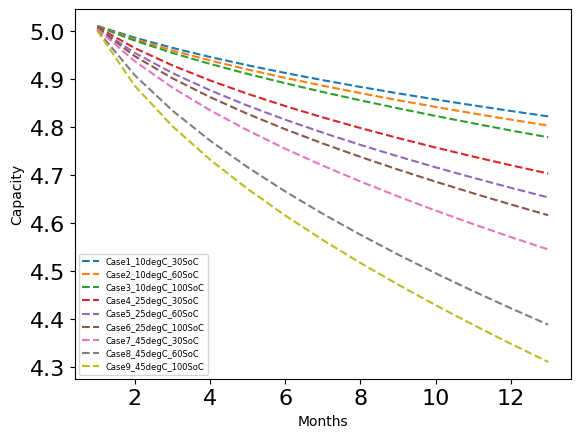

In [ ]:
atol = 1e-6
rtol = 1e-6

cycles_per_day = 1
days_per_year = 365 #365
months_per_year = 12
years_for_sim = 1
days_per_month = 30 #days
termination_capacity = 70
time_per_cycle = 24/cycles_per_day #in hours
#soc_upper_cutoff = 1
#soc_lower_cutoff = 0
#max_dod = soc_upper_cutoff - soc_lower_cutoff
crate_ref = 0.1
period_charge_discharge = 5
period_rest = 60
safe_solver = pybamm.IDAKLUSolver(atol=atol, rtol=rtol) #mode="safe", ,  dt_max= dt_max


simcase_list = []
experiment_list = []
no_steps_list = []

for n in range(len(df22)): #[4]
    tempC_case = df22["Temperature"][n]
    simcase = df22["Case"][n]
    
    soc_case = df22["SoC"][n]*0.01
    
    
    parameter_values.update({"Ambient temperature [K]": 298.15 + tempC_case,
                            "Initial temperature [K]": 298.15 + tempC_case})

    t_soc0 = (1-soc_case)*60/crate_ref #time in minutes
    t_soc_char = (soc_case)*60/crate_ref
    v0_soc_case = np.interp(soc_case, x01c_unique, y01c_unique)
    # exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
    # sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0)
    # sol0 = sim0.solve()

    # if soc_case == 1:
    #     model1 = model  #.set_initial_conditions_from(sol0)
    # else:
    exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C until {v0_soc_case}V")])
    sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0)
    sol0 = sim0.solve()
    model1 = model.set_initial_conditions_from(sol0)
        

    #discharge_time = int(60/crate*dod_case) # in minutes
    #charge_time = int(60/crate*dod_case) # in minutes
    #rest_time = int(time_per_cycle*60*calendar_time) #- discharge_time - charge_time
   

    discharge_string = f"Discharge at {crate_ref}C until 2.5V ({period_charge_discharge} minute period)"
    charge_string = f"Charge at {crate_ref}C until 4.2V ({period_charge_discharge} minute period)"
    rest_string = f"Rest for {days_per_month*24} hours ({period_rest} minute period)"
    charge_string_initialsoc = f"Charge at {crate_ref}C until {v0_soc_case}V"


    
    #list_of_steps_auto = list([rest_string, charge_string, discharge_string, charge_string_initialsoc])
    list_of_steps_auto = list([rest_string])

    steps_total = len(list_of_steps_auto)
        
    simcase_list.append(f"Case {simcase}: {tempC_case}degC, {soc_case*100}%SoC, {days_per_month} days calendaring for each cycle")
    no_steps_list.append(steps_total)
    experiment_list.append(list_of_steps_auto)
    exp1 = pybamm.Experiment(["Rest for 1 minute"]+list_of_steps_auto*months_per_year*years_for_sim, termination=f"{termination_capacity}% capacity")
    sim1 = pybamm.Simulation(model=model1, parameter_values=parameter_values, experiment=exp1, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Months"] =cycle1/(steps_total)-1 #*days_per_month
    df2["Capacity"] = Q1
    df2.to_csv(f"{current_directory}/paperStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")

    plt.plot(cycle1/(steps_total),Q1,"--", label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")
    plt.legend(fontsize=6)

plt.xlabel("Months")
plt.ylabel("Capacity")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)
df_conditions["simcase"] = simcase_list
df_conditions["Experiment"] = experiment_list
df_conditions["n_steps"] = no_steps_list

df_conditions.to_csv(f"{current_directory}/paperStudies/experiments_calendar.csv")



In [ ]:
 df22["Case"][26]

27

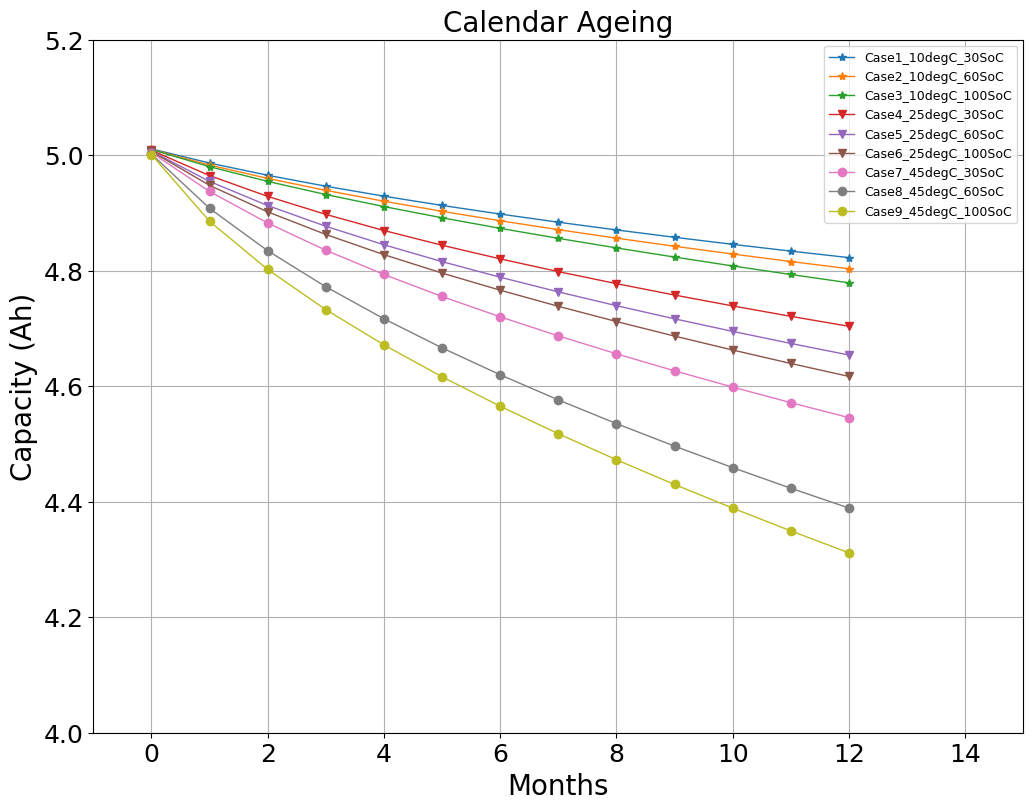

In [145]:
df3 = pd.read_csv(f"{current_directory}/paperStudies/Cases_for_Calendar_ageing.csv")
cycles_per_day =1
plt.figure(figsize=(12,9))
b =0
# for m in [5,11,12,13,15,17,23,27]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/FIstudies/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='v', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in range(1,4): #33,49, #range(27,54):#: #range(5): #
    b= b+1
    n = m-1
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='*', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

for m in range(4,7): #33,49, #range(27,54):#: #range(5): #
    b= b+1
    n = m-1
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='v', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

for m in range(7,10): #33,49, #range(27,54):#: #range(5): #
    b= b+1
    n = m-1
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    
    soc_case = df3["SoC"][n]*0.01
    
    df4 = pd.read_csv(f"{current_directory}/paperStudies/Case{simcase}_{tempC_case}degC_{soc_case*100}SoC_{days_per_month}calendardays_percycle.csv")
    plt.plot(df4["Months"]-1, df4["Capacity"]*1,marker='o', markevery=1,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{int(soc_case*100)}SoC")

# for m in [59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
#     b= b+1
#     n = m-1
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/FIstudies/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Days"], df4["Capacity Retention"]*100,marker='o', markevery=50,linewidth=1, label =f"Case{b}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Months',fontsize=20)
plt.ylabel('Capacity (Ah)',fontsize=20)
plt.title('Calendar Ageing',fontsize=20)
plt.ylim([4.0, 5.2])
plt.xlim([-1, 15])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

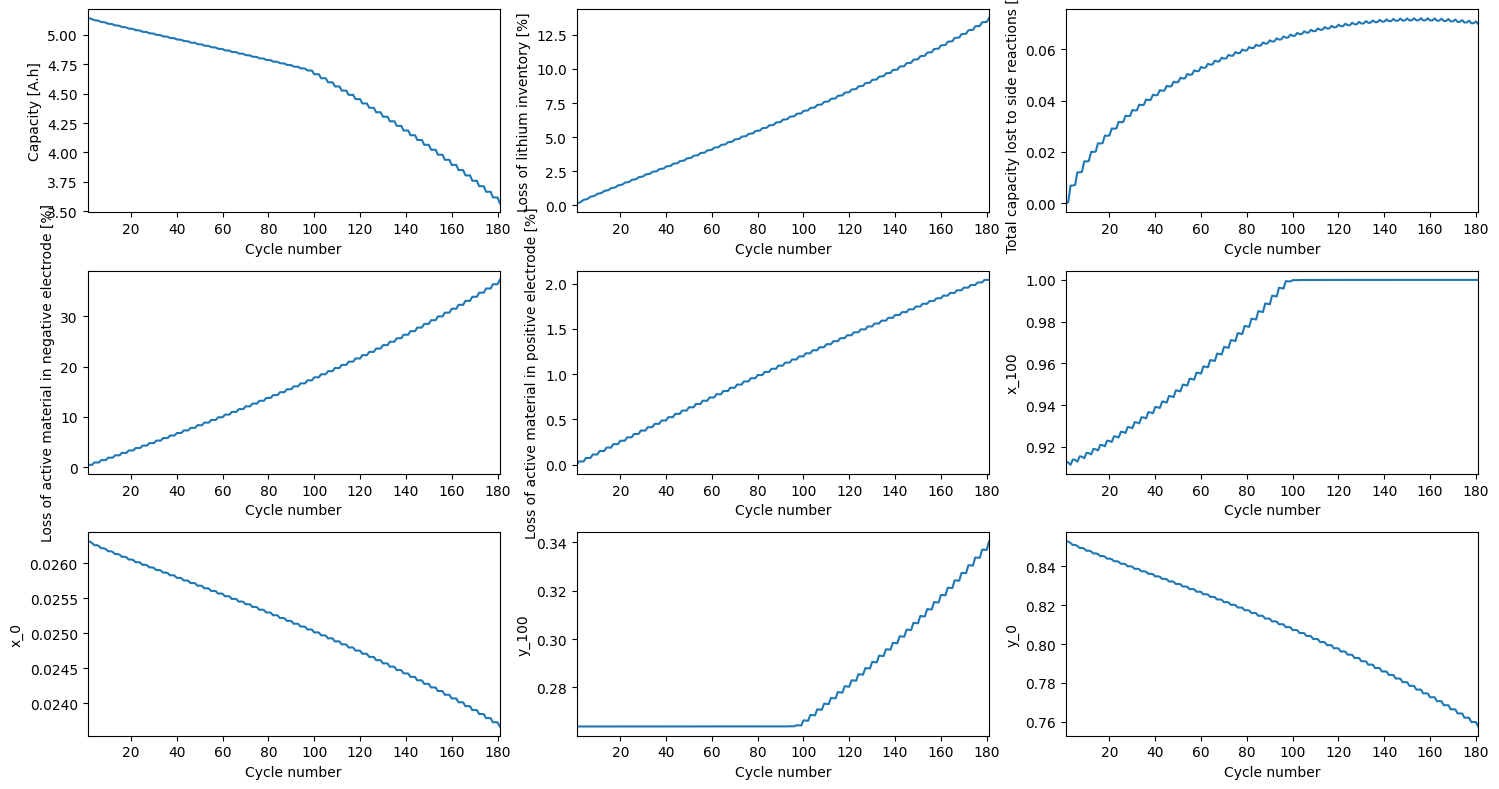

array([[<Axes: xlabel='Cycle number', ylabel='Capacity [A.h]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of lithium inventory [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Total capacity lost to side reactions [A.h]'>],
       [<Axes: xlabel='Cycle number', ylabel='Loss of active material in negative electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of active material in positive electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='x_100'>],
       [<Axes: xlabel='Cycle number', ylabel='x_0'>,
        <Axes: xlabel='Cycle number', ylabel='y_100'>,
        <Axes: xlabel='Cycle number', ylabel='y_0'>]], dtype=object)

In [ ]:
pybamm.plot_summary_variables(sim1.solution,output_variables='Capacity [A.h]')

In [ ]:
model1.variable_names()

['Time [s]',
 'Time [min]',
 'Time [h]',
 'x [m]',
 'x_n [m]',
 'x_s [m]',
 'x_p [m]',
 'r_n [m]',
 'r_p [m]',
 'Current variable [A]',
 'Total current density [A.m-2]',
 'Current [A]',
 'C-rate',
 'Discharge capacity [A.h]',
 'Throughput capacity [A.h]',
 'Discharge energy [W.h]',
 'Throughput energy [W.h]',
 'Negative electrode interface utilisation variable',
 'X-averaged negative electrode interface utilisation variable',
 'Negative electrode interface utilisation',
 'X-averaged negative electrode interface utilisation',
 'Positive electrode interface utilisation variable',
 'X-averaged positive electrode interface utilisation variable',
 'Positive electrode interface utilisation',
 'X-averaged positive electrode interface utilisation',
 'Negative particle crack length [m]',
 'X-averaged negative particle crack length [m]',
 'Negative particle cracking rate [m.s-1]',
 'X-averaged negative particle cracking rate [m.s-1]',
 'Positive particle crack length [m]',
 'X-averaged positive 

In [ ]:
sol1.plot(["Discharge capacity [A.h]", 'LLI [%]','LAM_pe [%]', 'LAM_ne [%]',  
            
            'X-averaged positive electrode extent of lithiation','X-averaged negative electrode extent of lithiation',
             ])

interactive(children=(FloatSlider(value=0.0, description='t', max=1416.5653548366645, step=14.165653548366645)…

In [ ]:
pybamm.dynamic_plot(sim1)

interactive(children=(FloatSlider(value=0.0, description='t', max=5377.855134721298, step=53.77855134721298), …

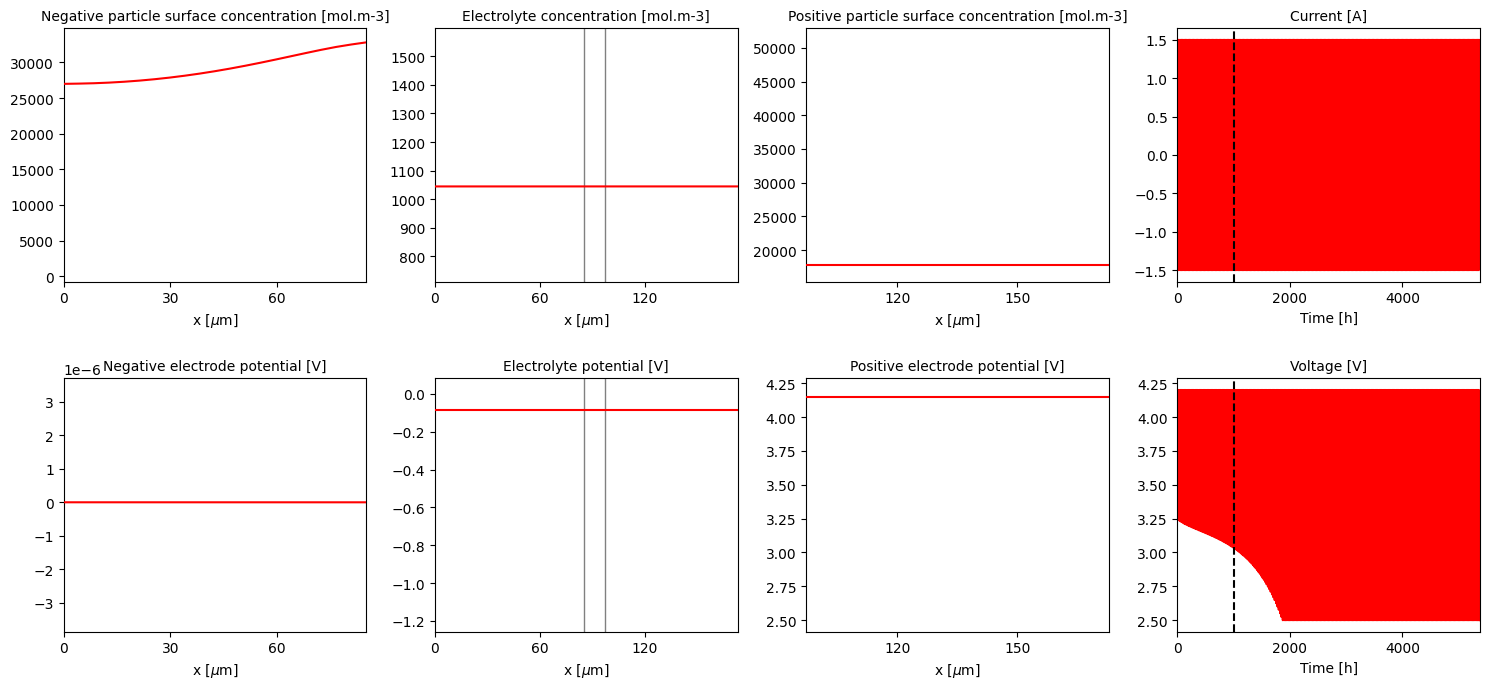

In [ ]:
plot = pybamm.QuickPlot(sim1)
plot.plot(1000)

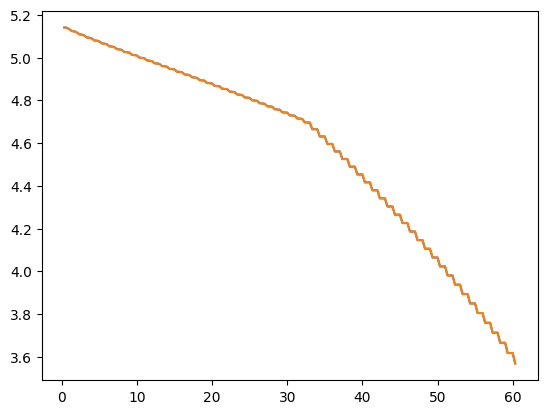

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
LLI = sim1.solution.summary_variables["Capacity [A.h]"]
LAMpe = sim1.solution.summary_variables["Capacity [A.h]"]
LAMne = sim1.solution.summary_variables["Capacity [A.h]"]
x100 = sim1.solution.summary_variables["Capacity [A.h]"]
x0 = sim1.solution.summary_variables["Capacity [A.h]"]
y100 = sim1.solution.summary_variables["Capacity [A.h]"]
y0 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]/(steps_total*cycles_per_day)
plt.plot(cycle1, Q1,)
plt.plot(cycle1,LLI)

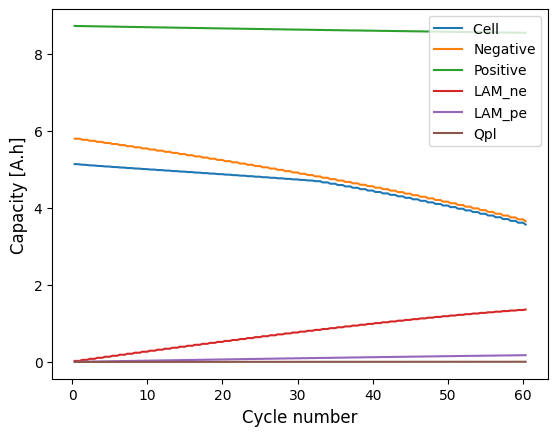

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
Qnes = sim1.solution.summary_variables["Negative electrode capacity [A.h]"]
Qpes = sim1.solution.summary_variables["Positive electrode capacity [A.h]"]
Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
cycle1s = sim1.solution.summary_variables["Cycle number"]/(steps_total*cycles_per_day)

r1 = [a*b/100 for a, b in zip(mlam_n,Qnes)]
r2 = [a*b/100 for a, b in zip(mlam_p,Qpes)]
plt.plot(cycle1s, Q1, label="Cell ")
plt.plot(cycle1s, Qnes, label="Negative")
plt.plot(cycle1s, Qpes, label="Positive")
plt.plot(cycle1s, r1, label="LAM_ne")
plt.plot(cycle1s, r2, label="LAM_pe")
plt.plot(cycle1s, Qpl, label="Qpl")

plt.xlabel('Cycle number',fontsize=12)
plt.ylabel('Capacity [A.h]',fontsize=12)
plt.legend()


In [ ]:
type(mlam_n)

list

In [ ]:
sol1.plot(["Discharge capacity [A.h]", "Negative electrode capacity [A.h]","Positive electrode capacity [A.h]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=5377.855134721298, step=53.77855134721298), …

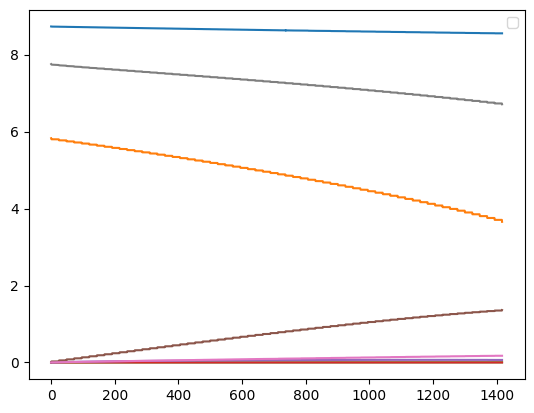

In [ ]:
Qp = sol1["Positive electrode capacity [A.h]"].entries
Qn = sol1["Negative electrode capacity [A.h]"].entries
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
Qlin = sol1['Loss of capacity to negative lithium plating [A.h]'].entries
Qlip= sol1['Loss of capacity to positive lithium plating [A.h]'].entries
Qsein = sol1['Loss of capacity to negative SEI [A.h]'].entries
Qlitot = sol1["Total lithium capacity [A.h]"].entries

mlam_n = sol1['Loss of active material in negative electrode [%]'].entries
mlam_p = sol1['Loss of active material in positive electrode [%]'].entries
tt = sol1["Time [h]"].entries
Qcell = sol1["Discharge capacity [A.h]"].entries
plt.figure()
plt.plot(tt, Qp, tt, Qn, tt, Qlin,tt, Qlip, tt, Qsein,tt, mlam_n*Qn*0.01, tt, mlam_p*Qp*0.01, tt, Qlitot,)
#plt.plot(tt,Qcell )
plt.legend()

In [ ]:
print(model.variables["Discharge capacity [A.h]"])
print(sol1["Discharge capacity [A.h]"].entries)

Discharge capacity [A.h]
[0.         0.125      0.25       ... 3.65184016 3.77684016 3.90104391]


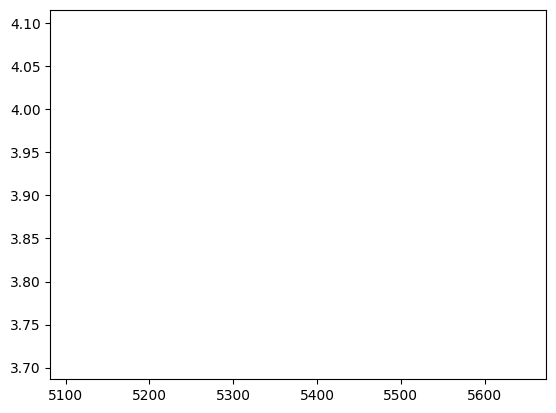

In [ ]:
plt.plot(sol1["Time [h]"].entries[-1], sol1["Discharge capacity [A.h]"].entries[-1] )

In [ ]:
sim1.plot(["Discharge capacity [A.h]"])

interactive(children=(FloatSlider(value=0.0, description='t', max=5377.855134721298, step=53.77855134721298), …